# Exemplo: Dimensionamento de treino
-----------------------

Este exemplo mostra como avaliar o desempenho de um modelo com base no tamanho do conjunto de treino.

Os dados utilizados são uma variação do [conjunto de dados de clima australiano](https://www.kaggle.com/jsphyg/weather-dataset-rattle-package) do Kaggle. Você pode baixá-lo [aqui](https://github.com/tvdboom/ExperionML/blob/master/examples/datasets/weatherAUS.csv). O objetivo deste conjunto é prever se vai chover amanhã treinando um classificador binário com a variável alvo `RainTomorrow`.

### Carregar os dados

In [1]:
# Import packages
import pandas as pd
from experionml import ExperionMLClassifier

In [2]:
# Carregar os dados
X = pd.read_csv("./datasets/weatherAUS.csv")

# Let's have a look
X.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,MelbourneAirport,18.0,26.9,21.4,7.0,8.9,SSE,41.0,W,SSE,...,95.0,54.0,1019.5,1017.0,8.0,5.0,18.5,26.0,Yes,0
1,Adelaide,17.2,23.4,0.0,NaN,NaN,S,41.0,S,WSW,...,59.0,36.0,1015.7,1015.7,NaN,NaN,17.7,21.9,No,0
2,Cairns,18.6,24.6,7.4,3.0,6.1,SSE,54.0,SSE,SE,...,78.0,57.0,1018.7,1016.6,3.0,3.0,20.8,24.1,Yes,0
3,Portland,13.6,16.8,4.2,1.2,0.0,ESE,39.0,ESE,ESE,...,76.0,74.0,1021.4,1020.5,7.0,8.0,15.6,16.0,Yes,1
4,Walpole,16.4,19.9,0.0,NaN,NaN,SE,44.0,SE,SE,...,78.0,70.0,1019.4,1018.9,NaN,NaN,17.4,18.1,No,0


## Executar o pipeline

In [3]:
# Inicialize o experionml e prepare os dados
experionml = ExperionMLClassifier(X, verbose=2, random_state=1)
experionml.clean()
experionml.impute(strat_num="median", strat_cat="most_frequent", max_nan_rows=0.8)
experionml.encode()

<< ================== ExperionML ================== >>

Configuração ==================== >>
Tarefa do algoritmo: Binary classification.

Estatísticas do conjunto de dados ==================== >>
Formato: (142193, 22)
Tamanho do conjunto de train: 113755
Tamanho do conjunto de test: 28438
-------------------------------------
Memória: 25.03 MB


Escalonado: False
Valores ausentes: 316559 (10.1%)
Atributos categóricos: 5 (23.8%)
Duplicatas: 45 (0.0%)

Ajustando Cleaner...
Limpando os dados...


Ajustando Imputer...


Imputando valores ausentes...


 --> Removendo 161 amostras por conterem mais de 16 valores ausentes.
 --> Imputando 481 valores ausentes com median (12.0) na coluna MinTemp.
 --> Imputando 265 valores ausentes com median (22.6) na coluna MaxTemp.
 --> Imputando 1354 valores ausentes com median (0.0) na coluna Rainfall.
 --> Imputando 60682 valores ausentes com median (4.8) na coluna Evaporation.
 --> Imputando 67659 valores ausentes com median (8.4) na coluna Sunshine.
 --> Imputando 9187 valores ausentes com most_frequent (W) na coluna WindGustDir.
 --> Imputando 9127 valores ausentes com median (39.0) na coluna WindGustSpeed.
 --> Imputando 9852 valores ausentes com most_frequent (N) na coluna WindDir9am.
 --> Imputando 3617 valores ausentes com most_frequent (SE) na coluna WindDir3pm.
 --> Imputando 1187 valores ausentes com median (13.0) na coluna WindSpeed9am.
 --> Imputando 2469 valores ausentes com median (19.0) na coluna WindSpeed3pm.
 --> Imputando 1613 valores ausentes com median (70.0) na coluna Humidity9

Ajustando Encoder...


Codificando colunas categóricas...
 --> Aplicando Target-encoding à variável Location. Ela contém 49 classes.
 --> Aplicando Target-encoding à variável WindGustDir. Ela contém 16 classes.
 --> Aplicando Target-encoding à variável WindDir9am. Ela contém 16 classes.
 --> Aplicando Target-encoding à variável WindDir3pm. Ela contém 16 classes.
 --> Aplicando Ordinal-encoding à variável RainToday. Ela contém 2 classes.


In [4]:
# Analise o impacto do tamanho do conjunto de treino em um modelo LR
experionml.train_sizing("LR", train_sizes=10, n_bootstrap=5)


Training ========================= >>
Metric: f1


Run: 0 =========================== >>
Models: LR01
Size of training set: 11362 (10%)
Size of test set: 28408


Results for LogisticRegression:
Fit ---------------------------------------------


Train evaluation --> f1: 0.563


Test evaluation --> f1: 0.5854
Time elapsed: 1.652s


Bootstrap ---------------------------------------
Evaluation --> f1: 0.5849 ± 0.002
Time elapsed: 4.278s
-------------------------------------------------
Time: 5.931s


Resultados finais ==================== >>
Tempo total: 5.984s
-------------------------------------
LogisticRegression --> f1: 0.5849 ± 0.002




Run: 1 =========================== >>
Models: LR02
Size of training set: 22724 (20%)
Size of test set: 28408


Results for LogisticRegression:
Fit ---------------------------------------------


...

LogisticRegression --> f1: 0.5846 ± 0.002


Run: 9 =========================== >>
Models: LR10
Size of training set: 113624 (100%)
Size of test set: 28408


Results for LogisticRegression:
Fit ---------------------------------------------


Train evaluation --> f1: 0.5858


Test evaluation --> f1: 0.5848
Time elapsed: 3.988s


Bootstrap ---------------------------------------
Evaluation --> f1: 0.5848 ± 0.0007
Time elapsed: 5.736s
-------------------------------------------------
Time: 9.724s


Resultados finais ==================== >>
Tempo total: 9.836s
-------------------------------------


LogisticRegression --> f1: 0.5848 ± 0.0007


## Analisar os resultados

In [5]:
# Os resultados agora são multi-index, em que frac é a fração
# do conjunto de treino usada para ajustar o modelo. Os nomes dos modelos
# também terminam com a fração, sem o ponto
experionml.results

,,f1_train,f1_test,time_fit,f1_bootstrap,time_bootstrap,time
frac,model,,,,,,
0.100000,LR01,0.562100,0.584800,1.652387,0.584922,4.278186,5.930573
0.200000,LR02,0.583200,0.584600,2.776146,0.585234,5.141516,7.917662
0.300000,LR03,0.580000,0.585200,2.509890,0.586118,5.624884,8.134774
0.400000,LR04,0.584500,0.585700,1.881077,0.586348,4.859517,6.740594
0.500000,LR05,0.583300,0.586500,3.016830,0.585384,5.565937,8.582767
0.600000,LR06,0.583100,0.583200,2.641838,0.584891,4.967879,7.609717
0.700000,LR07,0.587800,0.585800,2.905258,0.585235,5.392664,8.297922
0.800000,LR08,0.591600,0.588600,3.514330,0.585269,8.379559,11.893889
0.900000,LR09,0.585600,0.583300,3.106406,0.584633,6.345352,9.451758


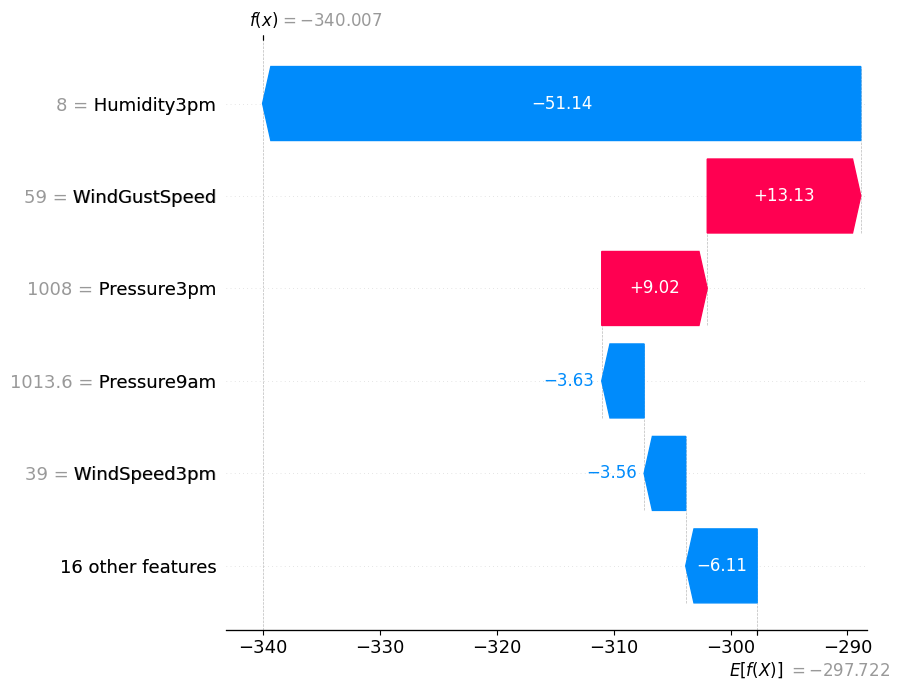

In [6]:
# Todo modelo pode ser acessado pelo nome
experionml.lr05.plot_shap_waterfall(show=6)

In [7]:
# Plote os resultados de train sizing
experionml.plot_learning_curve()